# 10 — Advanced Model Optimization

## Machine-Learning-Assisted Discovery of Quantum Materials

### Objective

The previous experiments achieved:

- Random-test R² ≈ 0.8195
- Chemical-system GroupKFold R² ≈ 0.7324

This notebook investigates whether the predictive performance can be improved using:

1. stronger ensemble regressors,
2. improved preprocessing,
3. two-stage zero/nonzero band-gap modeling,
4. cross-validation-based model selection,
5. chemical-system-aware validation.

### Important methodological rule

The final test set remains untouched during model selection.

All optimization is performed using the training data.

The test set is used only for the final evaluation.

### Main question

Can a more advanced modeling strategy improve band-gap prediction without
sacrificing scientifically meaningful validation?

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    KFold,
    GroupKFold,
)
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    ExtraTreesClassifier,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"

RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

RANDOM_STATE = 42

print("Project root:", ROOT)
print("Data:", DATA)
print("Results:", RESULTS)

Project root: F:\Quantum-materials
Data: F:\Quantum-materials\data
Results: F:\Quantum-materials\results


In [10]:
# ============================================================
# LOAD STRUCTURE-ENHANCED DATASET
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd().resolve()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"

DATASET_FILE = (
    DATA /
    "structural_enhanced_features.csv"
)

if not DATASET_FILE.exists():
    raise FileNotFoundError(
        f"""
Dataset not found:

{DATASET_FILE}

Run the save cell in Notebook 08 first.
"""
    )

df = pd.read_csv(
    DATASET_FILE
)

print("Dataset loaded successfully.")
print()
print("File:", DATASET_FILE)
print("Shape:", df.shape)

Dataset loaded successfully.

File: F:\Quantum-materials\data\structural_enhanced_features.csv
Shape: (93902, 36)


In [13]:
TARGET = "target_bandgap"

all_features = [
    c for c in df.columns
    if c != TARGET
]

print("Number of features:", len(all_features))
print(all_features)

Number of features: 35
['num_elements', 'total_atoms', 'mean_atomic_number', 'min_atomic_number', 'max_atomic_number', 'mean_atomic_mass', 'min_atomic_mass', 'max_atomic_mass', 'mean_atomic_radius', 'min_atomic_radius', 'max_atomic_radius', 'crys', 'spg_number', 'mean_electronegativity', 'min_electronegativity', 'max_electronegativity', 'electronegativity_difference', 'mean_ionization_energy', 'mean_electron_affinity', 'mean_s_valence', 'mean_p_valence', 'mean_d_valence', 'mean_f_valence', 'mean_period', 'mean_group', 'num_sites', 'volume', 'volume_per_atom', 'density', 'lattice_a', 'lattice_b', 'lattice_c', 'lattice_alpha', 'lattice_beta', 'lattice_gamma']


In [14]:
# ============================================================
# USE EXACT NOTEBOOK 08 FEATURES
# ============================================================

TARGET = "target_bandgap"

all_features = [
    column
    for column in df.columns
    if column != TARGET
]

print("Target:", TARGET)
print("Number of features:", len(all_features))

print("\nFeatures:")
for i, feature in enumerate(all_features, start=1):
    print(f"{i:2d}. {feature}")

assert len(all_features) == 35, (
    f"Expected 35 features, found {len(all_features)}"
)

Target: target_bandgap
Number of features: 35

Features:
 1. num_elements
 2. total_atoms
 3. mean_atomic_number
 4. min_atomic_number
 5. max_atomic_number
 6. mean_atomic_mass
 7. min_atomic_mass
 8. max_atomic_mass
 9. mean_atomic_radius
10. min_atomic_radius
11. max_atomic_radius
12. crys
13. spg_number
14. mean_electronegativity
15. min_electronegativity
16. max_electronegativity
17. electronegativity_difference
18. mean_ionization_energy
19. mean_electron_affinity
20. mean_s_valence
21. mean_p_valence
22. mean_d_valence
23. mean_f_valence
24. mean_period
25. mean_group
26. num_sites
27. volume
28. volume_per_atom
29. density
30. lattice_a
31. lattice_b
32. lattice_c
33. lattice_alpha
34. lattice_beta
35. lattice_gamma


In [15]:
# ============================================================
# PREPARE MODEL DATA
# ============================================================

model_df = df[
    all_features + [TARGET]
].copy()

model_df = model_df.replace(
    [np.inf, -np.inf],
    np.nan
)

model_df = model_df.dropna(
    subset=[TARGET]
)

X = model_df[
    all_features
].copy()

y = model_df[
    TARGET
].copy()

X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget statistics:")
print(y.describe())

print(
    "\nZero band-gap:",
    (y == 0).sum()
)

print(
    "Nonzero band-gap:",
    (y > 0).sum()
)

X shape: (93902, 35)
y shape: (93902,)

Target statistics:
count    93902.000000
mean         0.578425
std          1.310606
min          0.000000
25%          0.000000
50%          0.000000
75%          0.243000
max         18.179000
Name: target_bandgap, dtype: float64

Zero band-gap: 67062
Nonzero band-gap: 26840


In [17]:
# ============================================================
# PREPARE DATA — KEEP ALL 35 FEATURES
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

print("Original X shape:", X.shape)

# Check missing values BEFORE imputation
missing_counts = X.isna().sum()

print("\nMissing values by feature:")
print(
    missing_counts[
        missing_counts > 0
    ].sort_values(
        ascending=False
    )
)

# Identify completely empty columns
all_nan_features = [
    column
    for column in X.columns
    if X[column].isna().all()
]

print(
    "\nCompletely NaN features:",
    all_nan_features
)

# ------------------------------------------------------------
# Impute
#
# keep_empty_features=True ensures that an all-NaN feature
# is not silently removed.
# ------------------------------------------------------------

imputer = SimpleImputer(
    strategy="median",
    keep_empty_features=True
)

X_imputed_array = imputer.fit_transform(X)

X_imputed = pd.DataFrame(
    X_imputed_array,
    columns=X.columns,
    index=X.index
)

print(
    "\nAfter imputation:",
    X_imputed.shape
)

assert X_imputed.shape[1] == 35

# ------------------------------------------------------------
# Stratified train/test split
# ------------------------------------------------------------

strata = (
    y > 0
).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.20,
    random_state=42,
    stratify=strata
)

print(
    "\nTraining shape:",
    X_train.shape
)

print(
    "Test shape:",
    X_test.shape
)

print(
    "\nTraining zero-gap fraction:",
    f"{(y_train == 0).mean():.4%}"
)

print(
    "Test zero-gap fraction:",
    f"{(y_test == 0).mean():.4%}"
)

Original X shape: (93902, 35)

Missing values by feature:
crys                      93902
mean_s_valence               57
mean_electron_affinity       57
mean_ionization_energy       57
mean_d_valence               57
mean_f_valence               57
mean_period                  57
mean_p_valence               57
mean_group                   57
max_atomic_radius            27
mean_atomic_radius           27
min_atomic_radius            27
dtype: int64

Completely NaN features: ['crys']

After imputation: (93902, 35)

Training shape: (75121, 35)
Test shape: (18781, 35)

Training zero-gap fraction: 71.4168%
Test zero-gap fraction: 71.4179%


In [18]:
# ============================================================
# ADVANCED MODEL COMPARISON
# ============================================================

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

models = {

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=1.0,
        random_state=42,
        n_jobs=-1,
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=1.0,
        random_state=42,
        n_jobs=-1,
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42,
    ),
}

results = []
model_predictions = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    model_predictions[name] = pred

    mae = mean_absolute_error(
        y_test,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    r2 = r2_score(
        y_test,
        pred
    )

    results.append({
        "Model": name,
        "MAE (eV)": mae,
        "RMSE (eV)": rmse,
        "R²": r2,
    })

    print(
        f"MAE  = {mae:.4f} eV"
    )
    print(
        f"RMSE = {rmse:.4f} eV"
    )
    print(
        f"R²   = {r2:.4f}"
    )

results_df = (
    pd.DataFrame(results)
    .sort_values(
        "R²",
        ascending=False
    )
)

print("\n========== MODEL COMPARISON ==========")

display(results_df)


Training Random Forest...
MAE  = 0.2493 eV
RMSE = 0.5490 eV
R²   = 0.8240

Training Extra Trees...
MAE  = 0.2496 eV
RMSE = 0.5689 eV
R²   = 0.8110

Training HistGradientBoosting...
MAE  = 0.3245 eV
RMSE = 0.6192 eV
R²   = 0.7761

========== MODEL COMPARISON ==========


,Model,MAE (eV),RMSE (eV),R²
0,Random Forest,0.249262,0.548986,0.823985
1,Extra Trees,0.249561,0.568860,0.811010
2,HistGradientBoosting,0.324519,0.619153,0.776115


In [19]:
# ============================================================
# TWO-STAGE ZERO / NONZERO MODEL
# ============================================================

from sklearn.ensemble import ExtraTreesClassifier

# ------------------------------------------------------------
# STAGE 1 — CLASSIFICATION
# ------------------------------------------------------------

y_train_binary = (
    y_train > 0
).astype(int)

y_test_binary = (
    y_test > 0
).astype(int)

classifier = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

print("Training zero/nonzero classifier...")

classifier.fit(
    X_train,
    y_train_binary
)

# Probability that material has nonzero band gap
prob_nonzero = classifier.predict_proba(
    X_test
)[:, 1]

# ------------------------------------------------------------
# STAGE 2 — REGRESSION ONLY ON NONZERO MATERIALS
# ------------------------------------------------------------

nonzero_mask = (
    y_train > 0
)

X_train_nonzero = X_train.loc[
    nonzero_mask
]

y_train_nonzero = y_train.loc[
    nonzero_mask
]

regressor = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1,
)

print("Training nonzero-band-gap regressor...")

regressor.fit(
    X_train_nonzero,
    y_train_nonzero
)

pred_nonzero = regressor.predict(
    X_test
)

# Probability-weighted prediction
two_stage_pred = (
    prob_nonzero *
    pred_nonzero
)

# ------------------------------------------------------------
# REGRESSION METRICS
# ------------------------------------------------------------

two_stage_mae = mean_absolute_error(
    y_test,
    two_stage_pred
)

two_stage_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        two_stage_pred
    )
)

two_stage_r2 = r2_score(
    y_test,
    two_stage_pred
)

print("\n========== TWO-STAGE MODEL ==========")

print(
    f"MAE  = {two_stage_mae:.4f} eV"
)

print(
    f"RMSE = {two_stage_rmse:.4f} eV"
)

print(
    f"R²   = {two_stage_r2:.4f}"
)

Training zero/nonzero classifier...
Training nonzero-band-gap regressor...

========== TWO-STAGE MODEL ==========
MAE  = 0.2481 eV
RMSE = 0.5743 eV
R²   = 0.8074


In [20]:
# ============================================================
# STAGE-1 CLASSIFICATION PERFORMANCE
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

classification_pred = (
    prob_nonzero >= 0.5
).astype(int)

accuracy = accuracy_score(
    y_test_binary,
    classification_pred
)

precision = precision_score(
    y_test_binary,
    classification_pred
)

recall = recall_score(
    y_test_binary,
    classification_pred
)

f1 = f1_score(
    y_test_binary,
    classification_pred
)

print("========== ZERO/NONZERO CLASSIFICATION ==========")

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1       : {f1:.4f}"
)

print("\nConfusion matrix:")

print(
    confusion_matrix(
        y_test_binary,
        classification_pred
    )
)

========== ZERO/NONZERO CLASSIFICATION ==========
Accuracy : 0.9168
Precision: 0.8645
Recall   : 0.8405
F1       : 0.8524

Confusion matrix:
[[12706   707]
 [  856  4512]]


In [21]:
# ============================================================
# FINAL RANDOM-TEST COMPARISON
# ============================================================

comparison_rows = []

for _, row in results_df.iterrows():

    comparison_rows.append({
        "Model": row["Model"],
        "MAE (eV)": row["MAE (eV)"],
        "RMSE (eV)": row["RMSE (eV)"],
        "R²": row["R²"],
    })

comparison_rows.append({
    "Model": "Two-stage Extra Trees",
    "MAE (eV)": two_stage_mae,
    "RMSE (eV)": two_stage_rmse,
    "R²": two_stage_r2,
})

final_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(
        "R²",
        ascending=False
    )
    .reset_index(drop=True)
)

display(final_comparison)

# Save
RESULTS.mkdir(
    parents=True,
    exist_ok=True
)

final_comparison.to_csv(
    RESULTS /
    "advanced_model_comparison.csv",
    index=False
)

print(
    "\nSaved:",
    RESULTS /
    "advanced_model_comparison.csv"
)

,Model,MAE (eV),RMSE (eV),R²
0,Random Forest,0.249262,0.548986,0.823985
1,Extra Trees,0.249561,0.568860,0.811010
2,Two-stage Extra Trees,0.248067,0.574281,0.807391
3,HistGradientBoosting,0.324519,0.619153,0.776115



Saved: F:\Quantum-materials\results\advanced_model_comparison.csv


In [22]:
# ============================================================
# IMPROVEMENT OVER ORIGINAL MODEL
# ============================================================

OLD_R2 = 0.819530
OLD_MAE = 0.238135
OLD_RMSE = 0.555889

best = final_comparison.iloc[0]

new_r2 = best["R²"]
new_mae = best["MAE (eV)"]
new_rmse = best["RMSE (eV)"]

print("========== IMPROVEMENT ==========")

print(
    f"Previous R² : {OLD_R2:.4f}"
)

print(
    f"New R²      : {new_r2:.4f}"
)

print(
    f"R² change   : {new_r2 - OLD_R2:+.4f}"
)

print()

print(
    f"Previous MAE : {OLD_MAE:.4f} eV"
)

print(
    f"New MAE      : {new_mae:.4f} eV"
)

print(
    f"MAE change   : {new_mae - OLD_MAE:+.4f} eV"
)

print()

print(
    f"Previous RMSE: {OLD_RMSE:.4f} eV"
)

print(
    f"New RMSE     : {new_rmse:.4f} eV"
)

print(
    f"RMSE change  : {new_rmse - OLD_RMSE:+.4f} eV"
)

print()
print("Best model:", best["Model"])

========== IMPROVEMENT ==========
Previous R² : 0.8195
New R²      : 0.8240
R² change   : +0.0045

Previous MAE : 0.2381 eV
New MAE      : 0.2493 eV
MAE change   : +0.0111 eV

Previous RMSE: 0.5559 eV
New RMSE     : 0.5490 eV
RMSE change  : -0.0069 eV

Best model: Random Forest


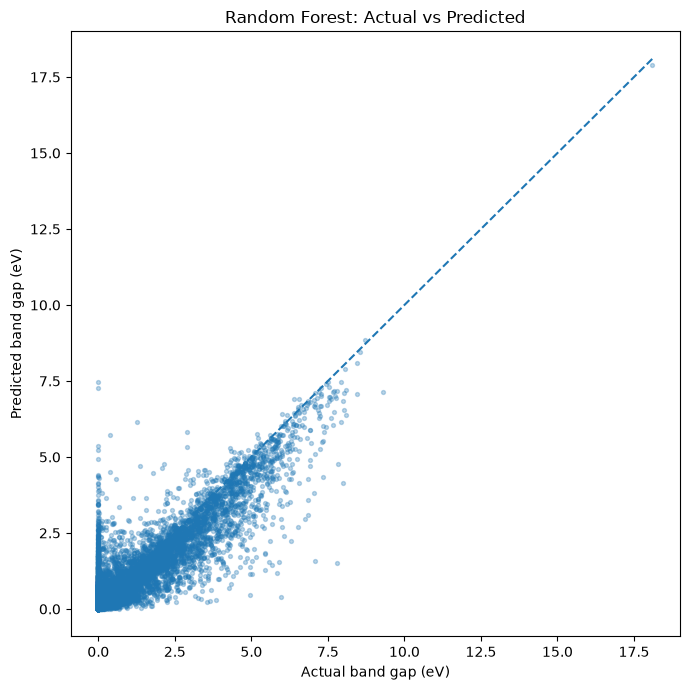

Saved: F:\Quantum-materials\figures\advanced_best_model_actual_vs_predicted.png


In [23]:
# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

best_model_name = best["Model"]

if best_model_name == "Two-stage Extra Trees":

    best_pred = two_stage_pred

else:

    best_pred = model_predictions[
        best_model_name
    ]

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    best_pred,
    s=8,
    alpha=0.30
)

low = min(
    y_test.min(),
    best_pred.min()
)

high = max(
    y_test.max(),
    best_pred.max()
)

plt.plot(
    [low, high],
    [low, high],
    linestyle="--"
)

plt.xlabel(
    "Actual band gap (eV)"
)

plt.ylabel(
    "Predicted band gap (eV)"
)

plt.title(
    f"{best_model_name}: Actual vs Predicted"
)

plt.tight_layout()

figure_path = (
    FIGURES /
    "advanced_best_model_actual_vs_predicted.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

In [24]:
# ============================================================
# 5-FOLD CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

# Select the best single-stage model
best_single_stage = results_df.iloc[0]["Model"]

if best_single_stage == "Extra Trees":

    def create_model():
        return ExtraTreesRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=1.0,
            random_state=42,
            n_jobs=-1,
        )

elif best_single_stage == "HistGradientBoosting":

    def create_model():
        return HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            random_state=42,
        )

else:

    def create_model():
        return RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=1.0,
            random_state=42,
            n_jobs=-1,
        )

for fold, (train_idx, val_idx) in enumerate(
    kf.split(X_train),
    start=1
):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    model = create_model()

    print(
        f"Training fold {fold}/5..."
    )

    model.fit(
        X_tr,
        y_tr
    )

    pred = model.predict(
        X_val
    )

    cv_results.append({
        "Fold": fold,
        "MAE (eV)": mean_absolute_error(
            y_val,
            pred
        ),
        "RMSE (eV)": np.sqrt(
            mean_squared_error(
                y_val,
                pred
            )
        ),
        "R²": r2_score(
            y_val,
            pred
        ),
    })

cv_df = pd.DataFrame(
    cv_results
)

display(cv_df)

print("\n========== CV MEAN ==========")

print(
    cv_df[
        ["MAE (eV)", "RMSE (eV)", "R²"]
    ].mean()
)

print("\n========== CV STD ==========")

print(
    cv_df[
        ["MAE (eV)", "RMSE (eV)", "R²"]
    ].std()
)

Training fold 1/5...
Training fold 2/5...
Training fold 3/5...
Training fold 4/5...
Training fold 5/5...


,Fold,MAE (eV),RMSE (eV),R²
0,1,0.266799,0.574725,0.795771
1,2,0.266489,0.575169,0.810943
2,3,0.263719,0.577059,0.808398
3,4,0.265240,0.578361,0.810239
4,5,0.268068,0.579570,0.805477



========== CV MEAN ==========
MAE (eV)     0.266063
RMSE (eV)    0.576976
R²           0.806166
dtype: float64

========== CV STD ==========
MAE (eV)     0.001652
RMSE (eV)    0.002061
R²           0.006183
dtype: float64


In [25]:
# ============================================================
# CHEMICAL-SYSTEM GROUPKFold
# ============================================================

from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

print("Starting chemical-system GroupKFold...")

# ------------------------------------------------------------
# We need a chemical-system group identifier.
#
# The original dataset contains the material ID/formula
# information, so first check which identifier is available.
# ------------------------------------------------------------

print("Available columns:")
print(df.columns.tolist())

Starting chemical-system GroupKFold...
Available columns:
['num_elements', 'total_atoms', 'mean_atomic_number', 'min_atomic_number', 'max_atomic_number', 'mean_atomic_mass', 'min_atomic_mass', 'max_atomic_mass', 'mean_atomic_radius', 'min_atomic_radius', 'max_atomic_radius', 'crys', 'spg_number', 'mean_electronegativity', 'min_electronegativity', 'max_electronegativity', 'electronegativity_difference', 'mean_ionization_energy', 'mean_electron_affinity', 'mean_s_valence', 'mean_p_valence', 'mean_d_valence', 'mean_f_valence', 'mean_period', 'mean_group', 'target_bandgap', 'num_sites', 'volume', 'volume_per_atom', 'density', 'lattice_a', 'lattice_b', 'lattice_c', 'lattice_alpha', 'lattice_beta', 'lattice_gamma']


In [26]:
print(df.columns.tolist())

['num_elements', 'total_atoms', 'mean_atomic_number', 'min_atomic_number', 'max_atomic_number', 'mean_atomic_mass', 'min_atomic_mass', 'max_atomic_mass', 'mean_atomic_radius', 'min_atomic_radius', 'max_atomic_radius', 'crys', 'spg_number', 'mean_electronegativity', 'min_electronegativity', 'max_electronegativity', 'electronegativity_difference', 'mean_ionization_energy', 'mean_electron_affinity', 'mean_s_valence', 'mean_p_valence', 'mean_d_valence', 'mean_f_valence', 'mean_period', 'mean_group', 'target_bandgap', 'num_sites', 'volume', 'volume_per_atom', 'density', 'lattice_a', 'lattice_b', 'lattice_c', 'lattice_alpha', 'lattice_beta', 'lattice_gamma']


In [27]:
# ============================================================
# CHECK WHETHER ORIGINAL DATA IS AVAILABLE
# ============================================================

from pathlib import Path

ROOT = Path.cwd().resolve()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

print("Project root:")
print(ROOT)

print("\nFiles in data/:")
for file in sorted((ROOT / "data").iterdir()):
    print(file.name)

Project root:
F:\Quantum-materials

Files in data/:
__init__.py
enhanced_material_descriptors.csv
processed
raw
structural_enhanced_features.csv


In [28]:
# ============================================================
# INSPECT ORIGINAL/ENHANCED DATASETS
# ============================================================

from pathlib import Path
import pandas as pd

ROOT = Path.cwd().resolve()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

files_to_check = [
    DATA / "enhanced_material_descriptors.csv",
    DATA / "structural_enhanced_features.csv",
]

for file in files_to_check:

    print("\n" + "=" * 70)
    print("FILE:", file.name)
    print("=" * 70)

    if not file.exists():
        print("FILE NOT FOUND")
        continue

    temp = pd.read_csv(file, nrows=5)

    print("Columns:")
    for i, col in enumerate(temp.columns, start=1):
        print(f"{i:2d}. {col}")

    print("\nShape information:")
    full_shape = pd.read_csv(file, nrows=1).shape
    print("Number of columns:", full_shape[1])


FILE: enhanced_material_descriptors.csv
Columns:
 1. num_elements
 2. total_atoms
 3. mean_atomic_number
 4. min_atomic_number
 5. max_atomic_number
 6. mean_atomic_mass
 7. min_atomic_mass
 8. max_atomic_mass
 9. mean_atomic_radius
10. min_atomic_radius
11. max_atomic_radius
12. crys
13. spg_number
14. mean_electronegativity
15. min_electronegativity
16. max_electronegativity
17. electronegativity_difference
18. mean_ionization_energy
19. mean_electron_affinity
20. mean_s_valence
21. mean_p_valence
22. mean_d_valence
23. mean_f_valence
24. mean_period
25. mean_group
26. target_bandgap

Shape information:
Number of columns: 26

FILE: structural_enhanced_features.csv
Columns:
 1. num_elements
 2. total_atoms
 3. mean_atomic_number
 4. min_atomic_number
 5. max_atomic_number
 6. mean_atomic_mass
 7. min_atomic_mass
 8. max_atomic_mass
 9. mean_atomic_radius
10. min_atomic_radius
11. max_atomic_radius
12. crys
13. spg_number
14. mean_electronegativity
15. min_electronegativity
16. max_el

In [29]:
# ============================================================
# INSPECT RAW DATASET FILES
# ============================================================

from pathlib import Path

RAW = ROOT / "data" / "raw"

print("Raw directory:")
print(RAW)

print("\nFiles:")
for path in sorted(RAW.rglob("*")):
    if path.is_file():
        print(f"{path.relative_to(RAW)}")

Raw directory:
F:\Quantum-materials\data\raw

Files:
